In [1]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.neighbors import kneighbors_graph
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

from torch_geometric.nn import SAGEConv

In [2]:
import pandas as pd

files = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"
]

dfs = []

for file in files:
    print("Loading:", file)
    df = pd.read_csv(file, encoding='latin1', low_memory=False)
    dfs.append(df)

print("All files loaded successfully")

Loading: Monday-WorkingHours.pcap_ISCX.csv
Loading: Tuesday-WorkingHours.pcap_ISCX.csv
Loading: Wednesday-workingHours.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading: Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
All files loaded successfully


In [3]:
import pandas as pd
import numpy as np

# 1. MERGE
data = pd.concat(dfs, ignore_index=True)

print("Merged shape:", data.shape)

# 2. CLEAN COLUMN NAMES (VERY IMPORTANT)
data.columns = data.columns.str.strip()

# 3. REMOVE INF / NaN
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data = data.dropna().reset_index(drop=True)

print("After cleaning:", data.shape)

# 4. CHECK LABEL COLUMN NAME
print("Columns:", data.columns)

# usually it's 'Label'
target_col = "Label"

# 5. LABEL DISTRIBUTION
print("\nRaw label distribution:")
print(data[target_col].value_counts())

Merged shape: (3119345, 85)
After cleaning: (2827876, 85)
Columns: Index(['Flow ID', 'Source IP', 'Source Port', 'Destination IP',
       'Destination Port', 'Protocol', 'Timestamp', 'Flow Duration',
       'Total Fwd Packets', 'Total Backward Packets',
       'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
      

In [4]:
# Convert to binary: BENIGN = 0, ATTACK = 1
data[target_col] = data[target_col].apply(lambda x: 0 if x == "BENIGN" else 1)

print("\nBinary distribution:")
print(data[target_col].value_counts())


Binary distribution:
Label
0    2271320
1     556556
Name: count, dtype: int64


In [5]:
# Define features and target FIRST
X = data.drop(columns=[target_col])
y = data[target_col]

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())

X shape: (2827876, 84)
y distribution:
 Label
0    2271320
1     556556
Name: count, dtype: int64


In [6]:
# Drop constant columns
X = X.loc[:, X.nunique() > 1]

print("After removing constants:", X.shape)

After removing constants: (2827876, 76)


In [7]:
# Recombine to remove duplicates safely
df_full = X.copy()
df_full[target_col] = y.values

before = df_full.shape[0]

df_full = df_full.drop_duplicates()

after = df_full.shape[0]

print("Before:", before)
print("After:", after)
print("Removed duplicates:", before - after)

Before: 2827876
After: 2827677
Removed duplicates: 199


In [8]:
X = df_full.drop(columns=[target_col])
X = X.select_dtypes(include=[np.number])
y = df_full[target_col]

In [9]:
from sklearn.model_selection import train_test_split

# Use cleaned + deduplicated data
X = df_full.drop(columns=[target_col])
y = df_full[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (2262141, 76)
Test: (565536, 76)


In [10]:
import numpy as np

# Hash rows for comparison
train_hash = set(map(tuple, X_train.values))
test_hash = set(map(tuple, X_test.values))

overlap = len(train_hash & test_hash)

print("Overlap between train & test:", overlap)

Overlap between train & test: 0


In [11]:
# Only keep numeric (safe)
X_train = X_train.select_dtypes(include=[np.number])
X_test = X_test.select_dtypes(include=[np.number])

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
#AE features

In [14]:
import torch
import torch.nn as nn

class AE(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 32)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon, z

In [15]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AE(input_dim=X_train_scaled.shape[1]).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

X_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)

losses = []
epochs = 10

for epoch in range(epochs):
    model.train()
    
    optimizer.zero_grad()
    recon, _ = model(X_tensor)
    
    loss = criterion(recon, X_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 1.0108
Epoch 2, Loss: 0.9992
Epoch 3, Loss: 0.9885
Epoch 4, Loss: 0.9779
Epoch 5, Loss: 0.9667
Epoch 6, Loss: 0.9545
Epoch 7, Loss: 0.9409
Epoch 8, Loss: 0.9260
Epoch 9, Loss: 0.9096
Epoch 10, Loss: 0.8917


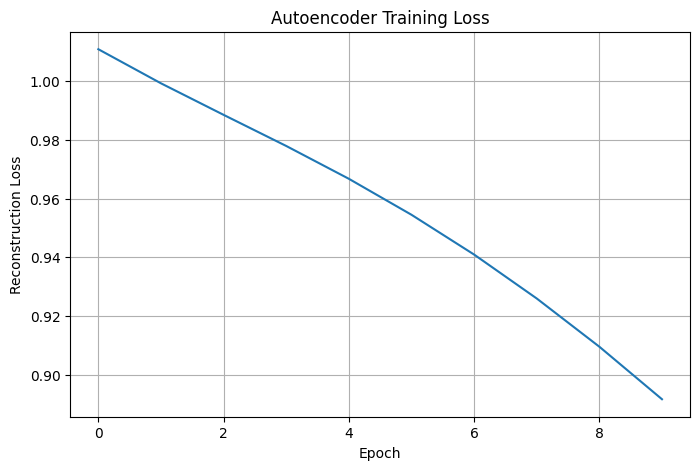

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("Autoencoder Training Loss")
plt.grid(True)

plt.savefig("ae_loss.png", dpi=300)
plt.show()

In [17]:
#graph Construct

In [18]:
import torch
import numpy as np

model.eval()

with torch.no_grad():
    X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
    X_test_tensor  = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

    train_recon, Z_train = model(X_train_tensor)
    test_recon,  Z_test  = model(X_test_tensor)

Z_train = Z_train.cpu().numpy()
Z_test  = Z_test.cpu().numpy()

train_recon = train_recon.cpu().numpy()
test_recon  = test_recon.cpu().numpy()

# Reconstruction error
re_train = np.mean(np.square(X_train_scaled - train_recon), axis=1).reshape(-1, 1)
re_test  = np.mean(np.square(X_test_scaled - test_recon), axis=1).reshape(-1, 1)

In [19]:
train_features = np.hstack([Z_train, re_train])
test_features  = np.hstack([Z_test, re_test])

In [20]:
import numpy as np

sample_size = 50000

idx = np.random.choice(len(Z_train), sample_size, replace=False)

X_gnn = Z_train[idx]
y_gnn = y_train.iloc[idx].values

print(X_gnn.shape)
print(y_gnn.shape)

(50000, 32)
(50000,)


In [21]:
from sklearn.neighbors import kneighbors_graph
import torch
from torch_geometric.data import Data
import numpy as np

A = kneighbors_graph(
    X_gnn,
    n_neighbors=10,
    mode="connectivity",
    include_self=False
)

edge_index = torch.tensor(
    np.array(A.nonzero()),
    dtype=torch.long
)

x = torch.tensor(X_gnn, dtype=torch.float32)
y = torch.tensor(y_gnn, dtype=torch.long)

data = Data(
    x=x,
    edge_index=edge_index,
    y=y
)

print(data)

Data(x=[50000, 32], edge_index=[2, 500000], y=[50000])


In [22]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = GCNConv(32, 16)
        self.conv2 = GCNConv(16, 2)

    def forward(self, data):

        x = data.x
        edge_index = data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = self.conv2(x, edge_index)

        return x

In [23]:
device = torch.device("cpu")

model = GCN().to(device)

data = data.to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

losses = []

for epoch in range(20):

    model.train()

    optimizer.zero_grad()

    out = model(data)

    loss = F.cross_entropy(out, data.y)

    loss.backward()

    optimizer.step()

    losses.append(loss.item())

    print(
        f"Epoch {epoch+1:02d} | Loss = {loss.item():.4f}"
    )

Epoch 01 | Loss = 0.7111
Epoch 02 | Loss = 0.6278
Epoch 03 | Loss = 0.5631
Epoch 04 | Loss = 0.5125
Epoch 05 | Loss = 0.4723
Epoch 06 | Loss = 0.4409
Epoch 07 | Loss = 0.4166
Epoch 08 | Loss = 0.3977
Epoch 09 | Loss = 0.3835
Epoch 10 | Loss = 0.3732
Epoch 11 | Loss = 0.3663
Epoch 12 | Loss = 0.3618
Epoch 13 | Loss = 0.3588
Epoch 14 | Loss = 0.3567
Epoch 15 | Loss = 0.3547
Epoch 16 | Loss = 0.3526
Epoch 17 | Loss = 0.3501
Epoch 18 | Loss = 0.3470
Epoch 19 | Loss = 0.3432
Epoch 20 | Loss = 0.3389


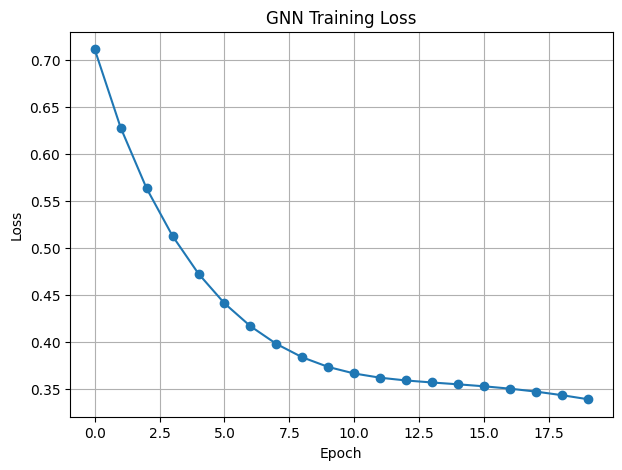

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(losses, marker='o')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GNN Training Loss")

plt.grid(True)

plt.savefig(
    "gnn_training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
model.eval()

with torch.no_grad():
    pred = model(data).argmax(dim=1)

acc = (pred == data.y).float().mean()

print("GNN Accuracy:", acc.item())

GNN Accuracy: 0.8737999796867371


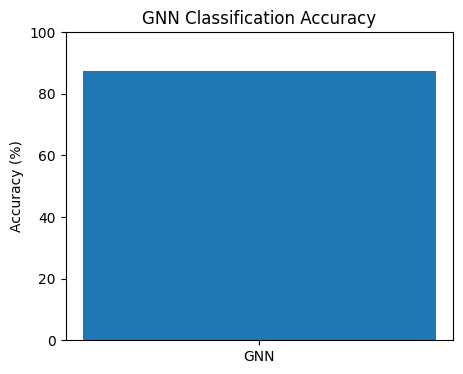

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

plt.bar(
    ["GNN"],
    [acc.item()*100]
)

plt.ylabel("Accuracy (%)")
plt.title("GNN Classification Accuracy")

plt.ylim(0,100)

plt.savefig(
    "gnn_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
print(edge_index.shape)
print(edge_index[:, :20])

torch.Size([2, 500000])
tensor([[    0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1],
        [45412, 15694,  8354, 33528, 38639, 19718, 31973, 38583, 16248, 13198,
           841,  2909,  9141,  9342, 15855, 37411, 39733, 47625, 22765, 12369]])


In [28]:
print(edge_index.min())
print(edge_index.max())

tensor(0)
tensor(49999)


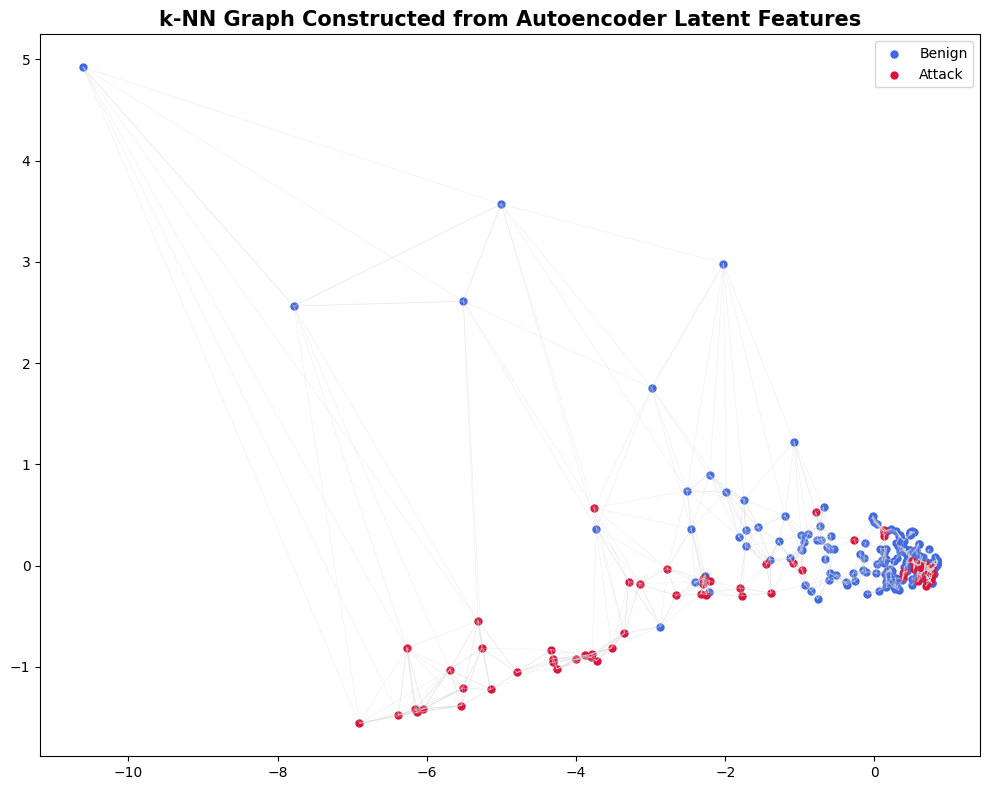

In [29]:
from sklearn.decomposition import PCA
from sklearn.neighbors import kneighbors_graph
import matplotlib.pyplot as plt
import numpy as np

sample_size = 500

idx = np.random.choice(
    len(Z_train),
    sample_size,
    replace=False
)

X_vis = Z_train[idx]
y_vis = y_train.iloc[idx].values

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_vis)

A = kneighbors_graph(
    X_2d,
    n_neighbors=7,
    mode='connectivity'
)

plt.figure(figsize=(10,8))

rows, cols = A.nonzero()

for i, j in zip(rows, cols):
    plt.plot(
        [X_2d[i,0], X_2d[j,0]],
        [X_2d[i,1], X_2d[j,1]],
        color='lightgray',
        alpha=0.3,
        linewidth=0.5
    )

plt.scatter(
    X_2d[y_vis==0,0],
    X_2d[y_vis==0,1],
    c='royalblue',
    s=25,
    label='Benign'
)

plt.scatter(
    X_2d[y_vis==1,0],
    X_2d[y_vis==1,1],
    c='crimson',
    s=25,
    label='Attack'
)

plt.title(
    "k-NN Graph Constructed from Autoencoder Latent Features",
    fontsize=15,
    weight='bold'
)
plt.savefig(
    "Figure_5_3_kNN_Graph.png",
    dpi=300,
    bbox_inches="tight"
)

plt.legend()
plt.tight_layout()
plt.show()

In [30]:
from sklearn.model_selection import train_test_split

X_small, _, y_small, _ = train_test_split(
    train_features,
    y_train,
    train_size=300000,
    stratify=y_train,
    random_state=42
)

In [31]:
#RF Model

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,      # faster
    max_depth=15,          # enough
    max_features="sqrt",   # big speed boost
    n_jobs=-1,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_small, y_small)

,n_estimators,100
,criterion,'gini'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
proba = rf.predict_proba(test_features)[:, 1]

In [34]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, proba)
f1 = 2 * (precision * recall) / (precision + recall + 1e-8)

target_recall = 0.99

valid_idx = np.where(recall >= target_recall)[0]

# pick the one with BEST precision among them
best_idx = valid_idx[np.argmax(precision[valid_idx])]

best_thresh = thresholds[best_idx]
pred = (proba > best_thresh).astype(int)

In [35]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, proba)
f1 = 2 * (precision * recall) / (precision + recall + 1e-8)

beta = 2

f2 = (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall + 1e-8)

best_thresh = thresholds[np.argmax(f2)]
pred = (proba > best_thresh).astype(int)

In [36]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(classification_report(y_test, pred))
print(confusion_matrix(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    454225
           1       0.91      0.99      0.95    111311

    accuracy                           0.98    565536
   macro avg       0.95      0.98      0.97    565536
weighted avg       0.98      0.98      0.98    565536

[[443067  11158]
 [   828 110483]]
ROC-AUC: 0.9986234431064613


In [37]:
print("Best threshold:", best_thresh)

Best threshold: 0.503492314445428


In [38]:
#visualization

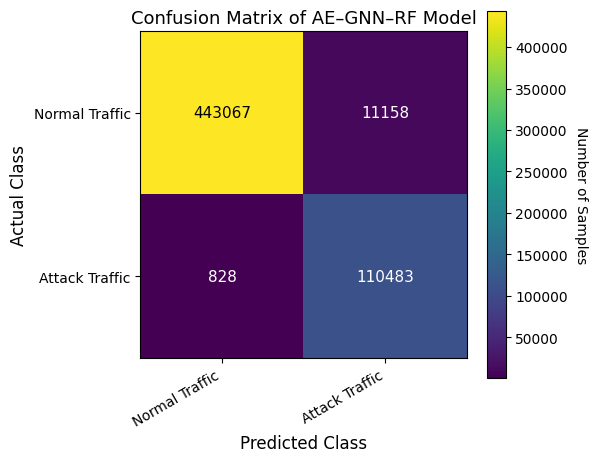

In [39]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Make sure prediction exists
y_pred = pred   # or use clf.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Class labels
classes = ["Normal Traffic", "Attack Traffic"]

# Create figure
fig, ax = plt.subplots(figsize=(6, 5))

# Plot heatmap (no manual color → clean default)
im = ax.imshow(cm)

# Colorbar
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Number of Samples", rotation=-90, va="bottom")

# Axis labels
ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)

ax.set_xlabel("Predicted Class", fontsize=12)
ax.set_ylabel("Actual Class", fontsize=12)

# Title
ax.set_title("Confusion Matrix of AE–GNN–RF Model", fontsize=13)

# Rotate x labels
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

# Add ONLY raw values (no %)
threshold = cm.max() / 2.

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i,
                f"{cm[i, j]}",
                ha="center", va="center",
                color="black" if cm[i, j] > threshold else "white",
                fontsize=11)

ax.grid(False)
plt.tight_layout()

# Save
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.savefig("confusion_matrix.eps", format='eps', bbox_inches="tight")

plt.show()

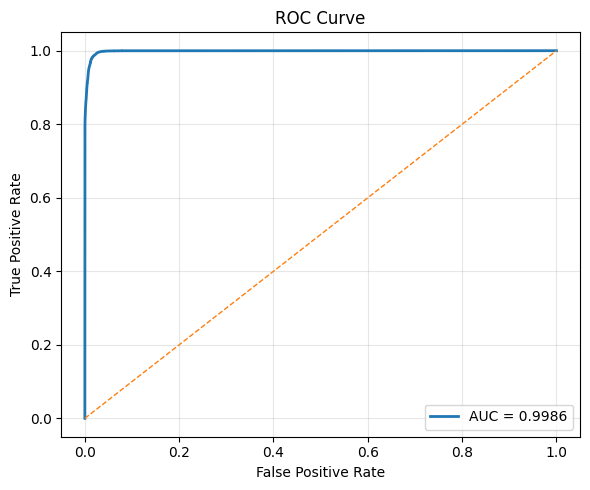

In [40]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--', linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")


plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

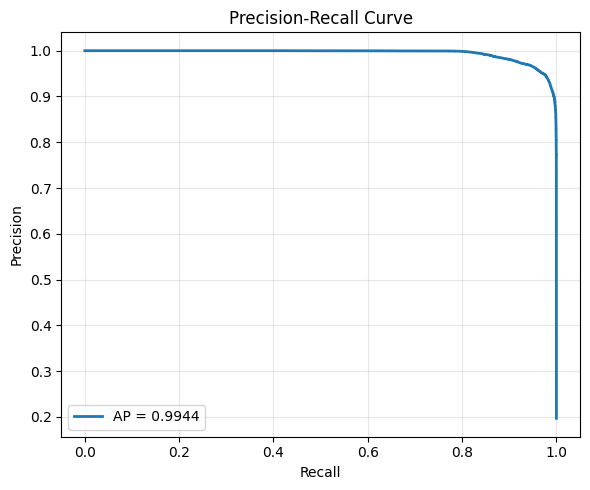

In [41]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, proba)
ap_score = average_precision_score(y_test, proba)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, linewidth=2, label=f"AP = {ap_score:.4f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("pr_curve.png", dpi=300, bbox_inches="tight")

plt.show()

In [42]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision (Attack)",
        "Recall (Attack)",
        "F1-score (Attack)",
        "ROC-AUC"
    ],
    "Value": [
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred),
        roc_auc_score(y_test, proba)
    ]
})

results["Value"] = results["Value"].apply(lambda x: f"{x:.4f}")

results

,Metric,Value
0,Accuracy,0.9788
1,Precision (Attack),0.9083
2,Recall (Attack),0.9926
3,F1-score (Attack),0.9485
4,ROC-AUC,0.9986


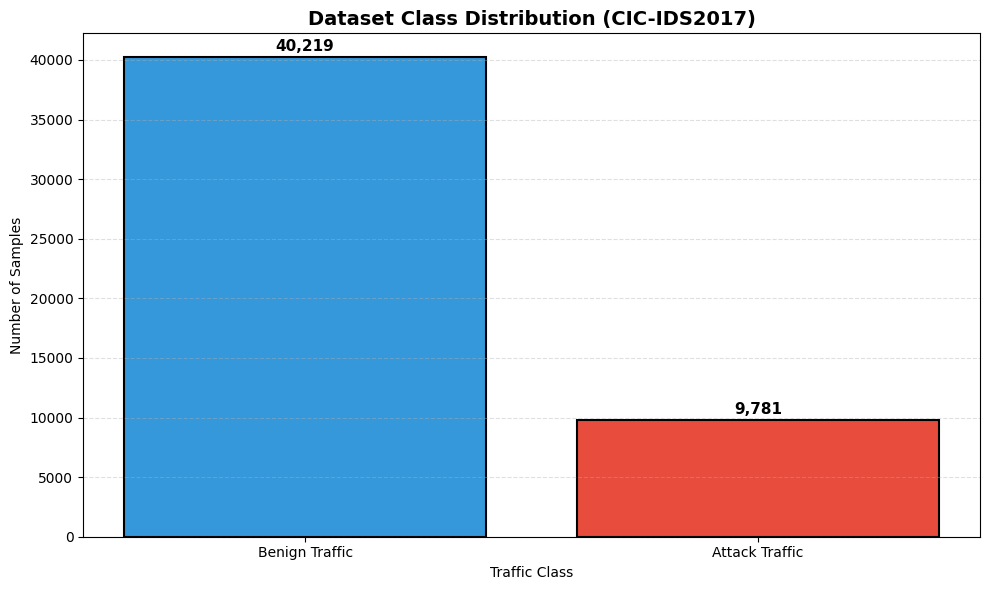

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

# Count binary classes
class_counts = pd.Series(y).value_counts().sort_index()

plt.figure(figsize=(10,6))

bars = plt.bar(
    ['Benign Traffic', 'Attack Traffic'],
    class_counts.values,
    color=['#3498DB', '#E74C3C'],
    edgecolor='black',
    linewidth=1.5
)

# Add values on bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 500,
        f'{int(bar.get_height()):,}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title('Dataset Class Distribution (CIC-IDS2017)',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Traffic Class')
plt.ylabel('Number of Samples')

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.savefig('Figure_5_1_Dataset_Class_Distribution.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

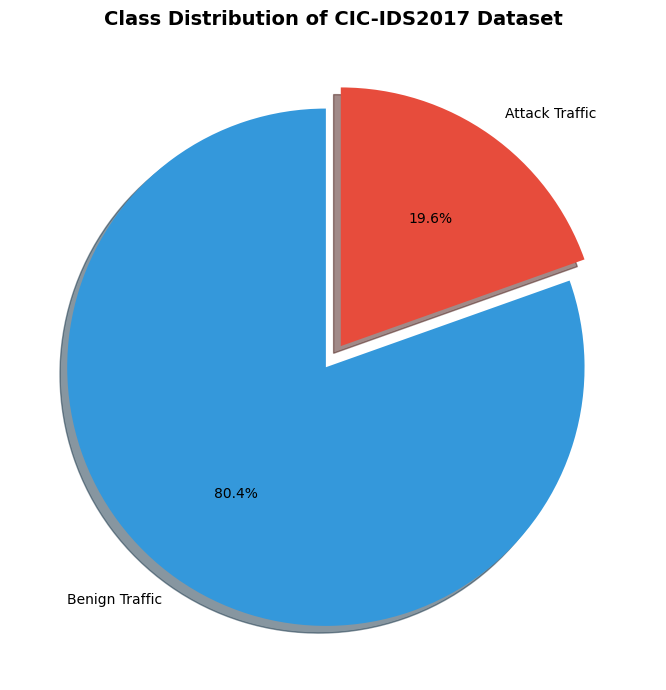

In [51]:
import matplotlib.pyplot as plt

labels = ['Benign Traffic', 'Attack Traffic']
sizes = [40219, 9781]
colors = ['#3498DB', '#E74C3C']

plt.figure(figsize=(7,7))

plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.05, 0.05),
    shadow=True
)

plt.title('Class Distribution of CIC-IDS2017 Dataset',
          fontsize=14,
          fontweight='bold')

plt.tight_layout()

plt.savefig('Figure_5_1_PieChart.png',
            dpi=600,
            bbox_inches='tight')

plt.show()